## COVID: Average daily increments

Calculate daily increments as an average of last N days.
Then recalculate them per 100k inhabitants to be comparable.
Show rankings in descending order.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Import cases data from Johns Hopkins github repo

In [2]:
confirmed_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv', index_col='Country/Region')
# group & sum by country, coz bigger countries are split to regions
cases = confirmed_df.groupby('Country/Region').sum()
cases.head()
# cases.loc['Czechia'].tail(30).plot()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,2/13/23,2/14/23,2/15/23,2/16/23,2/17/23,2/18/23,2/19/23,2/20/23,2/21/23,2/22/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,33.93911,67.709953,0,0,0,0,0,0,0,0,...,209011,209036,209056,209072,209083,209084,209107,209153,209181,209181
Albania,41.15330,20.168300,0,0,0,0,0,0,0,0,...,334255,334264,334264,334273,334291,334305,334314,334315,334336,334336
Algeria,28.03390,1.659600,0,0,0,0,0,0,0,0,...,271409,271409,271421,271424,271424,271425,271425,271426,271428,271431
Andorra,42.50630,1.521800,0,0,0,0,0,0,0,0,...,47860,47860,47860,47866,47866,47866,47866,47866,47866,47866
Angola,-11.20270,17.873900,0,0,0,0,0,0,0,0,...,105184,105184,105184,105184,105184,105184,105184,105184,105184,105205


Import population data from provided CSV

In [3]:
populations_data = pd.read_csv('populations.csv')
populations = populations_data.groupby('Location').sum()

Insert population data into cases dataframe

In [4]:
cases.insert(loc=0, column='Population', value = populations['PopTotal'])
cases = cases.loc[cases['Population'] > 1000]

In [5]:
# cases.T.Czechia.tail(90).plot()
# plt.yscale('log')
# diffs = cases.T.Sweden
# increments = diffs.rolling(window=2).apply(lambda x: x.iloc[-1] - x.iloc[0])
# increments.tail(14)

In [6]:
diffsCZ = cases.T.Czechia
incrementsCZ = diffsCZ.rolling(window=2).apply(lambda x: x.iloc[-1] - x.iloc[0])
incrementsCZ.tail(14)

2/9/23      646.0
2/10/23     574.0
2/11/23     694.0
2/12/23     135.0
2/13/23     100.0
2/14/23    1404.0
2/15/23    1157.0
2/16/23    1055.0
2/17/23     889.0
2/18/23    1008.0
2/19/23     131.0
2/20/23     107.0
2/21/23    1817.0
2/22/23    1433.0
Name: Czechia, dtype: float64

<AxesSubplot:>

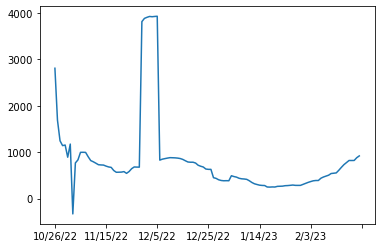

In [7]:
incrementsCZ.rolling(window=7).mean().tail(120).plot()

# Set number of days from which to calculate the average

In [8]:
N = 7

Calculate increment today vs N days ago, calculate daily average

In [9]:
cases['NdayIncrement'] = (cases.iloc[:,-1] - cases.iloc[:,-1-N])
cases['NdayAverage'] = cases['NdayIncrement'] / N

Recalculate per 100k inhabitants

In [10]:
cases['NdayIncrementPerPopulation'] = cases['NdayIncrement'] / cases['Population'] * 10000
cases['NdayAveragePerPopulation'] = cases['NdayAverage'] / cases['Population'] * 10000

Cherrypick data for results dataframe

In [11]:
result = cases.loc[:,['Population', 'NdayIncrement', 'NdayAverage', 'NdayIncrementPerPopulation' ,'NdayAveragePerPopulation']]

Sort results

In [12]:
top = result.sort_values(by=['NdayAveragePerPopulation'], ascending=False).head(50)
top

,Population,NdayIncrement,NdayAverage,NdayIncrementPerPopulation,NdayAveragePerPopulation
Country/Region,,,,,
Austria,9006.0,35099,5014.142857,38972.906951,5567.558136
Bahrain,1702.0,4609,658.428571,27079.905993,3868.557999
New Zealand,4822.0,8230,1175.714286,17067.606802,2438.229543
"Korea, South",51269.0,72482,10354.571429,14137.588016,2019.655431
Cyprus,1207.0,1516,216.571429,12560.066280,1794.295183
Germany,83784.0,98555,14079.285714,11762.985773,1680.426539
Japan,126476.0,116400,16628.571429,9203.327113,1314.761016
Georgia,3989.0,3553,507.571429,8906.994234,1272.427748
Costa Rica,5094.0,4471,638.714286,8776.992540,1253.856077


<AxesSubplot:xlabel='Country/Region'>

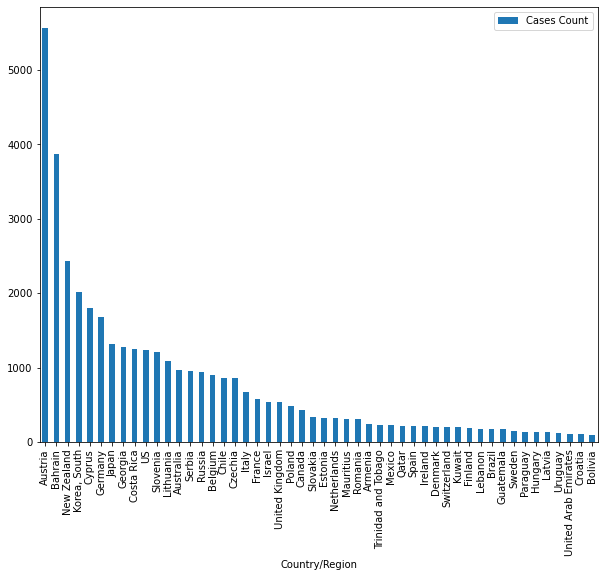

In [13]:
top.rename(columns = {'NdayAveragePerPopulation':'Cases Count'}, inplace = True)
top.plot(kind='bar', y='Cases Count', figsize=(10,8))